# AQI Prediction Project — Exploratory Data Analysis

In [80]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("assets", exist_ok=True)

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [34]:
import os
import hopsworks
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

True

In [82]:
HOPSWORKS_KEY = os.getenv("HOPSWORKS_API_KEY")

project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai",
    project="aqi_project_10pearls",
    api_key_value=HOPSWORKS_KEY
)

fs = project.get_feature_store()

fg = fs.get_feature_group(
    name="aqi_features",
    version=1
)

df = fg.read()
df.head()

2026-05-19 12:05:58,753 INFO: Closing external client and cleaning up certificates.
2026-05-19 12:05:58,756 INFO: Connection closed.
2026-05-19 12:05:58,757 INFO: Initializing external client
2026-05-19 12:05:58,757 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-19 12:06:00,958 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32913
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.01s) 


,timestamp,city,aqi,pm25,pm10,o3,no2,so2,co,temp,...,hour_sin,hour_cos,month_sin,month_cos,aqi_change_rate,aqi_rolling_6h,aqi_rolling_24h,target_aqi_3h,target_aqi_24h,target_aqi_72h
0,2026-05-04 03:00:00+00:00,Karachi,125.0,29.99,85.19,110.59,0.36,0.53,128.01,32.6,...,0.707107,0.707107,5.000000e-01,-8.660254e-01,0.0,150.0,139.583333,125.0,125.0,125.0
1,2025-12-25 05:00:00+00:00,Karachi,125.0,44.68,79.67,122.92,1.75,10.03,310.01,19.8,...,0.965926,0.258819,-2.449294e-16,1.000000e+00,0.0,125.0,147.916667,175.0,125.0,300.0
2,2025-10-20 15:00:00+00:00,Karachi,125.0,30.25,74.14,95.38,0.17,0.64,130.01,28.1,...,-0.707107,-0.707107,-8.660254e-01,5.000000e-01,0.0,125.0,125.000000,125.0,175.0,300.0
3,2026-03-31 21:00:00+00:00,Karachi,125.0,9.71,28.13,115.39,0.15,0.44,116.11,24.0,...,-0.707107,0.707107,1.000000e+00,6.123234e-17,0.0,125.0,125.000000,125.0,125.0,125.0
4,2025-11-02 00:00:00+00:00,Karachi,175.0,58.80,113.56,99.19,0.10,0.46,180.71,23.1,...,0.000000,1.000000,-5.000000e-01,8.660254e-01,0.0,175.0,227.083333,175.0,300.0,175.0


# Data Summary

In [87]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (8642, 28)
Columns: ['timestamp', 'city', 'aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'pressure', 'wind_speed', 'wind_deg', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'aqi_change_rate', 'aqi_rolling_6h', 'aqi_rolling_24h', 'target_aqi_3h', 'target_aqi_24h', 'target_aqi_72h']


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8642 entries, 0 to 8641
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype                  
---  ------           --------------  -----                  
 0   timestamp        8642 non-null   datetime64[us, Etc/UTC]
 1   city             8642 non-null   object                 
 2   aqi              8642 non-null   float64                
 3   pm25             8642 non-null   float64                
 4   pm10             8642 non-null   float64                
 5   o3               8642 non-null   float64                
 6   no2              8642 non-null   float64                
 7   so2              8642 non-null   float64                
 8   co               8642 non-null   float64                
 9   temp             8642 non-null   float64                
 10  humidity         8642 non-null   float64                
 11  pressure         8642 non-null   float64                
 12  wind_speed       864

In [86]:
df.isnull().sum().sort_values(ascending=False)

target_aqi_72h     47
target_aqi_24h     22
target_aqi_3h       1
city                0
aqi_rolling_24h     0
aqi_rolling_6h      0
aqi_change_rate     0
month_cos           0
month_sin           0
hour_cos            0
hour_sin            0
is_weekend          0
month               0
day_of_week         0
timestamp           0
wind_deg            0
wind_speed          0
pressure            0
humidity            0
temp                0
co                  0
so2                 0
no2                 0
o3                  0
pm10                0
pm25                0
aqi                 0
hour                0
dtype: int64

In [38]:
df_clean = df.dropna(subset=["target_aqi_24h", "target_aqi_72h"])

print("Original shape:", df.shape)
print("After dropping missing target rows:", df_clean.shape)

Original shape: (8642, 28)
After dropping missing target rows: (8595, 28)


In [39]:
print("Original rows:", df.shape[0])
print("Clean rows:", df_clean.shape[0])
print("Rows dropped:", df.shape[0] - df_clean.shape[0])

print("Original columns:", df.shape[1])
print("Clean columns:", df_clean.shape[1])

Original rows: 8642
Clean rows: 8595
Rows dropped: 47
Original columns: 28
Clean columns: 28


In [40]:
df_clean.isnull().sum().sort_values(ascending=False)

timestamp          0
city               0
target_aqi_24h     0
target_aqi_3h      0
aqi_rolling_24h    0
aqi_rolling_6h     0
aqi_change_rate    0
month_cos          0
month_sin          0
hour_cos           0
hour_sin           0
is_weekend         0
month              0
day_of_week        0
hour               0
wind_deg           0
wind_speed         0
pressure           0
humidity           0
temp               0
co                 0
so2                0
no2                0
o3                 0
pm10               0
pm25               0
aqi                0
target_aqi_72h     0
dtype: int64

# AQI Stats

In [41]:
df["aqi"].describe()

count    8642.000000
mean      139.232469
std        63.716909
min        25.000000
25%       125.000000
50%       125.000000
75%       175.000000
max       300.000000
Name: aqi, dtype: float64

# AQI Distribution

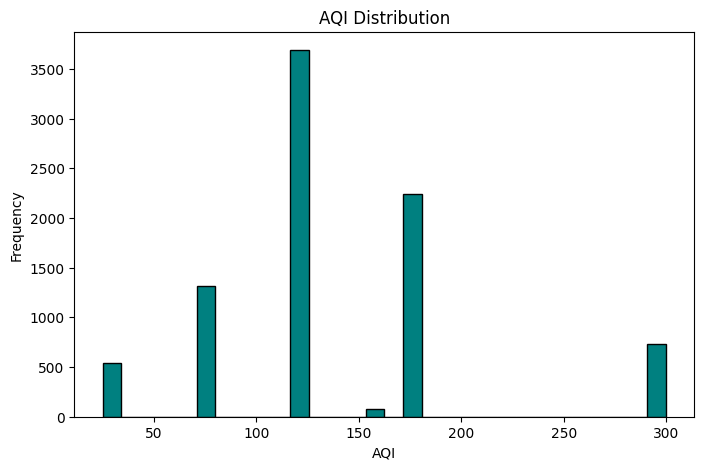

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["aqi"].dropna(), bins=30, color="teal", edgecolor="black")
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

# AQI category count

2026-05-19 11:55:48,120 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



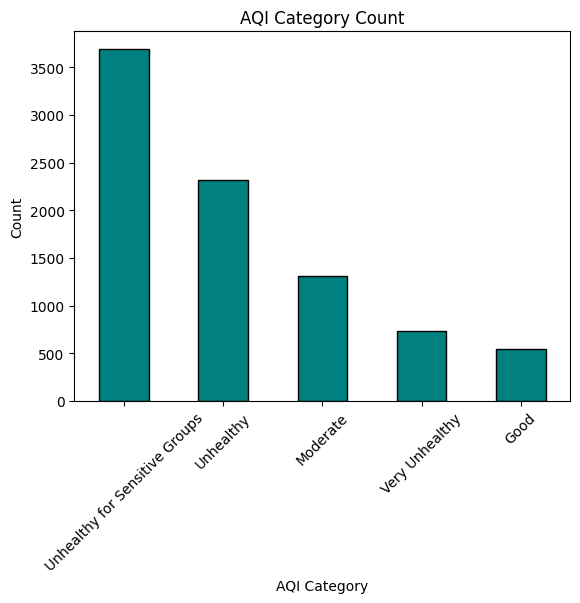

In [43]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df_clean["aqi_category"] = df_clean["aqi"].apply(aqi_category)

df_clean["aqi_category"].value_counts().plot(kind="bar", color="teal", edgecolor="black")
plt.title("AQI Category Count")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# AQI by day of week

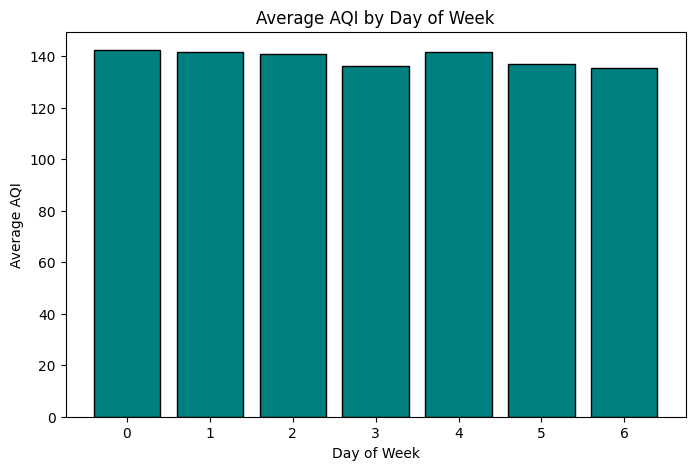

In [44]:
day_aqi = df_clean.groupby("day_of_week")["aqi"].mean()

plt.figure(figsize=(8,5))
plt.bar(day_aqi.index, day_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average AQI")
plt.show()

# AQI Trend Over Time

2026-05-19 11:55:48,269 WARNING: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



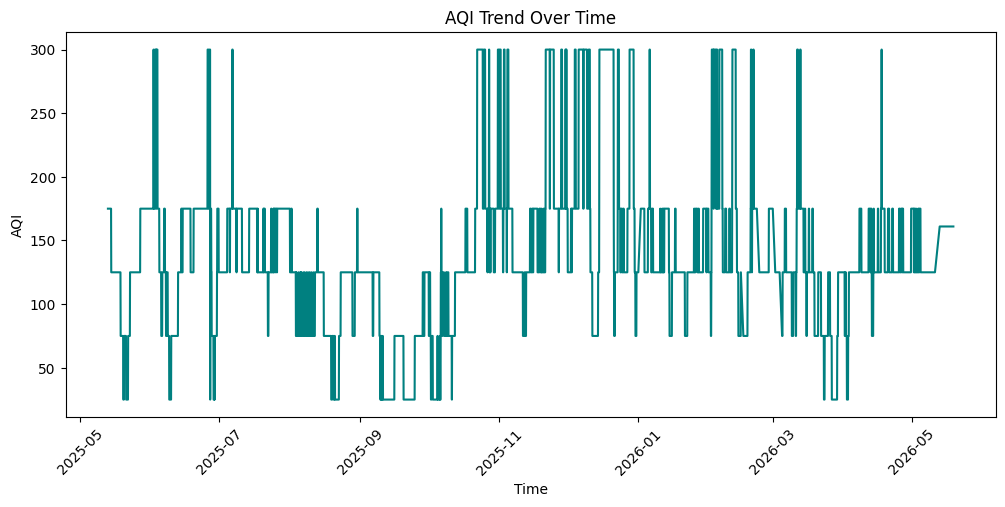

In [45]:
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

df_sorted = df_clean.sort_values("timestamp")

plt.figure(figsize=(12, 5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], color="teal")
plt.title("AQI Trend Over Time")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap

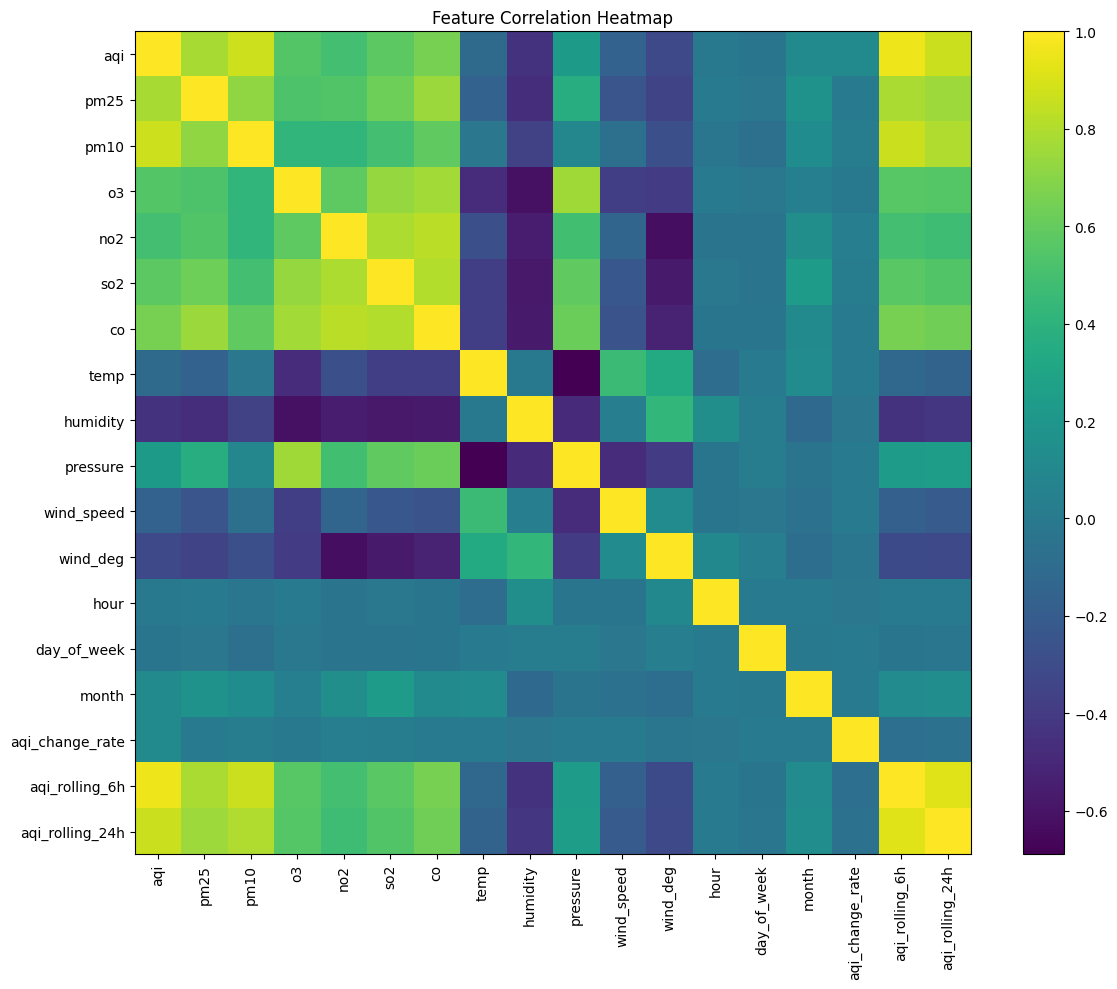

In [46]:
corr_cols = [
    "aqi", "pm25", "pm10", "o3", "no2", "so2", "co",
    "temp", "humidity", "pressure", "wind_speed", "wind_deg",
    "hour", "day_of_week", "month",
    "aqi_change_rate", "aqi_rolling_6h", "aqi_rolling_24h"
]

corr = df_clean[corr_cols].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="viridis", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [47]:
corr_with_aqi = df_clean.corr(numeric_only=True)["aqi"].sort_values(ascending=False)
corr_with_aqi

aqi                1.000000
aqi_rolling_6h     0.959194
target_aqi_3h      0.918482
pm10               0.869411
aqi_rolling_24h    0.866409
pm25               0.780447
target_aqi_24h     0.658253
co                 0.652041
so2                0.573833
o3                 0.550194
no2                0.494045
target_aqi_72h     0.363555
pressure           0.230109
month_cos          0.227710
month              0.121909
month_sin          0.121002
aqi_change_rate    0.118753
hour_sin           0.012944
hour              -0.005939
is_weekend        -0.030088
day_of_week       -0.032600
hour_cos          -0.032878
temp              -0.104225
wind_speed        -0.157100
wind_deg          -0.316166
humidity          -0.441827
Name: aqi, dtype: float64

# Average AQI by Hour

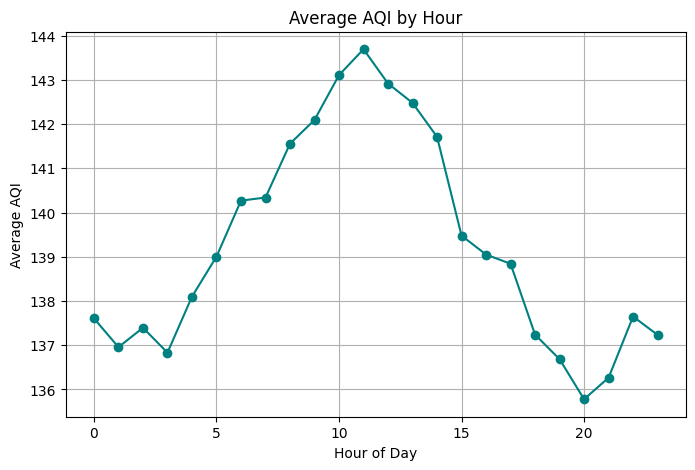

In [48]:
hourly_aqi = df_clean.groupby("hour")["aqi"].mean()
plt.figure(figsize=(8, 5))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o", color="teal")
plt.title("Average AQI by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

# Average AQI by Month

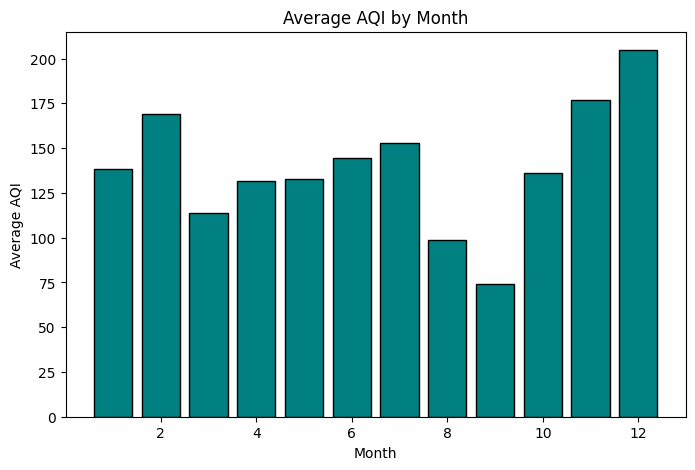

In [49]:
monthly_aqi = df_clean.groupby("month")["aqi"].mean()

plt.figure(figsize=(8, 5))
plt.bar(monthly_aqi.index, monthly_aqi.values, color="teal", edgecolor="black")
plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

# Pollutants vs AQI

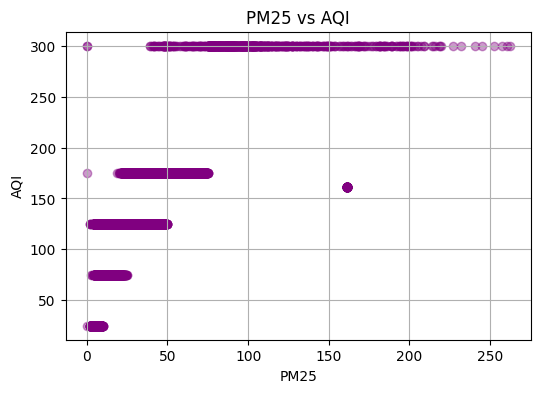

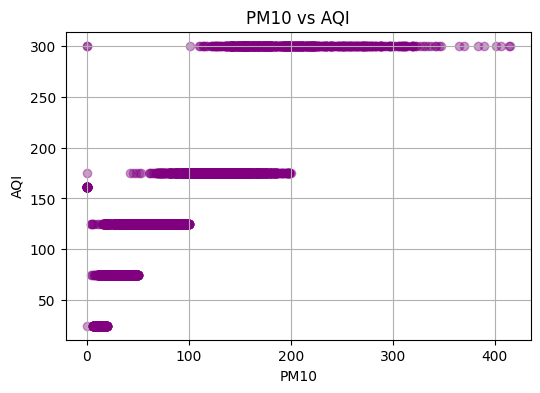

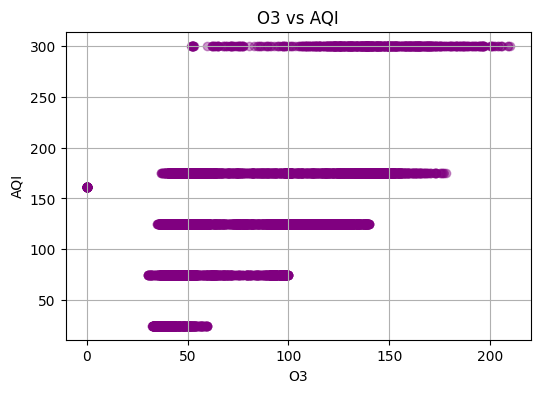

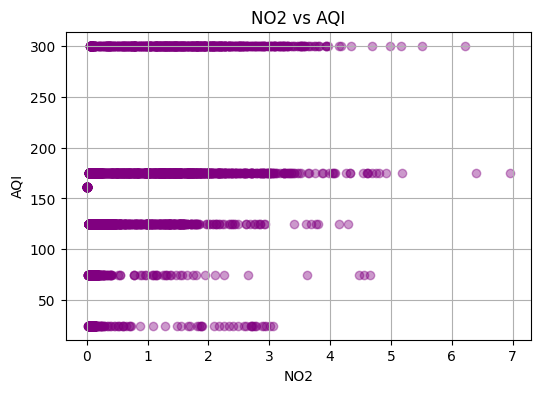

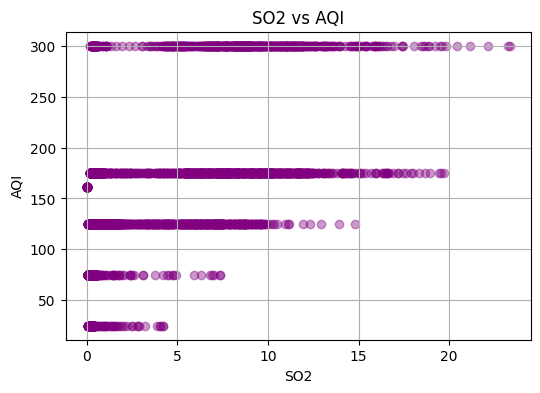

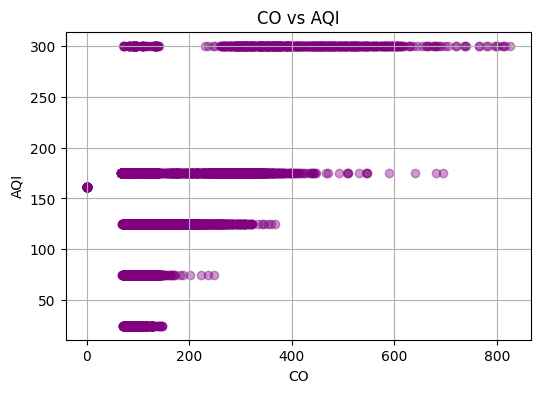

In [50]:
pollutants = ["pm25", "pm10", "o3", "no2", "so2", "co"]

for col in pollutants:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="purple")
    plt.title(f"{col.upper()} vs AQI")
    plt.xlabel(col.upper())
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()

# Weather vs AQI

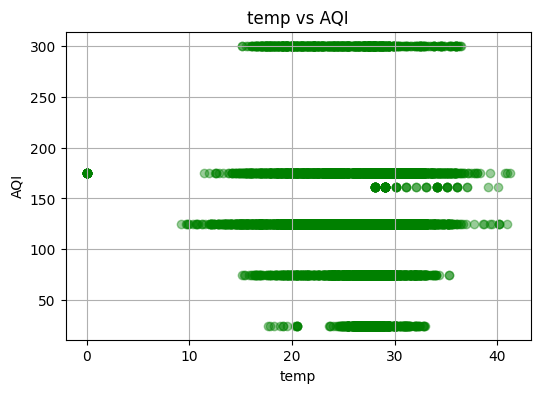

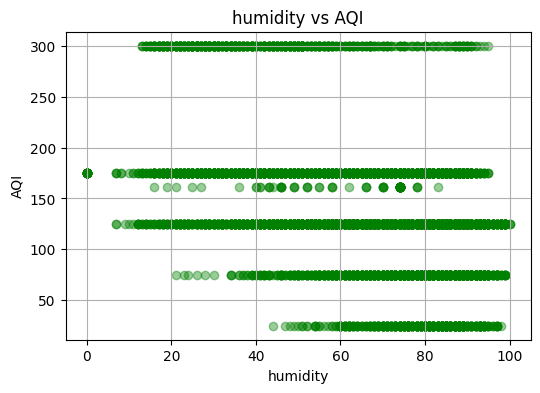

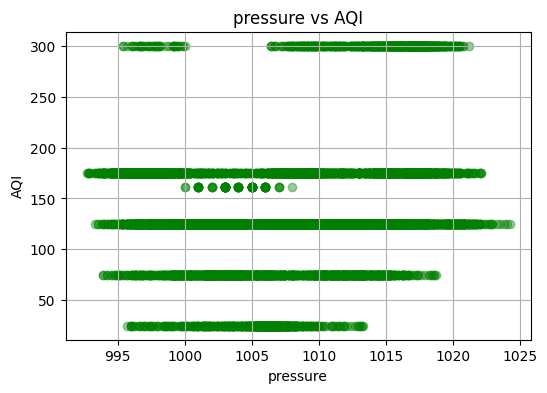

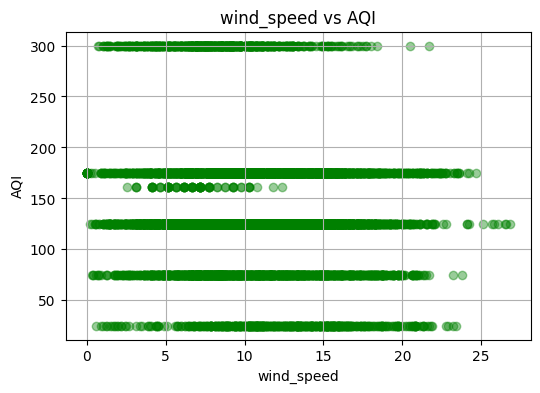

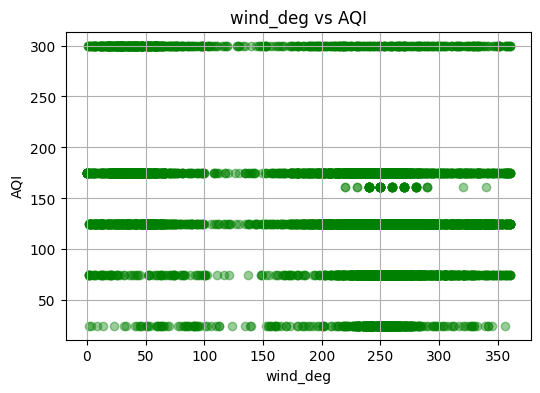

In [51]:
weather_cols = ["temp", "humidity", "pressure", "wind_speed", "wind_deg"]

for col in weather_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(df_clean[col], df_clean["aqi"], alpha=0.4, color="green")
    plt.title(f"{col} vs AQI")
    plt.xlabel(col)
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()

# Outliers

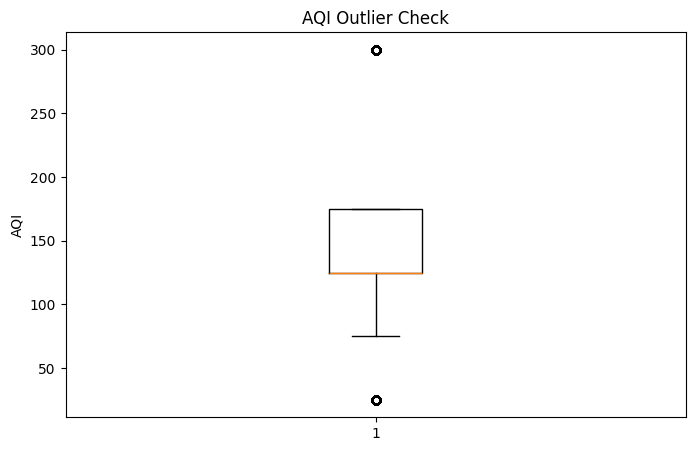

In [52]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["aqi"].dropna())
plt.title("AQI Outlier Check")
plt.ylabel("AQI")
plt.show()

# Rolling AQI trend

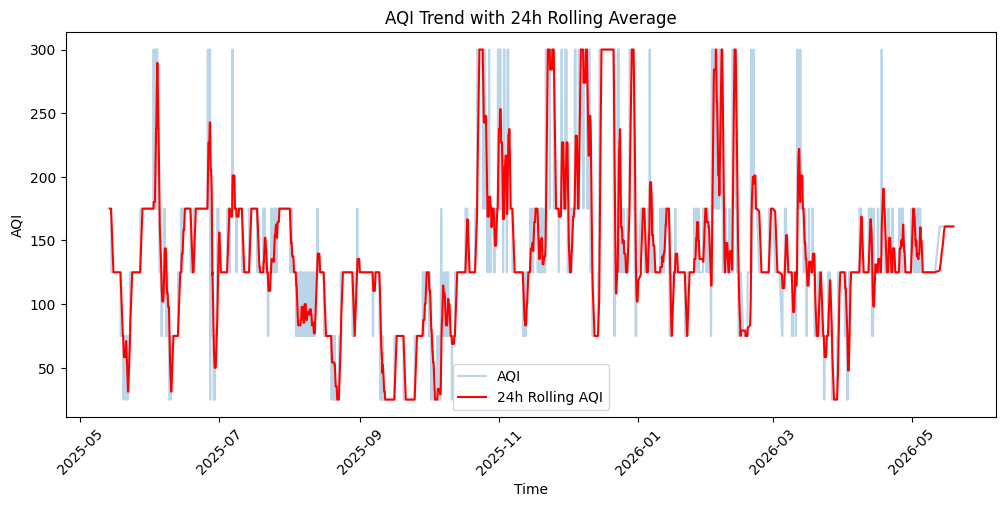

In [53]:
df_sorted = df_clean.sort_values("timestamp")
df_sorted["aqi_rolling_mean"] = df_sorted["aqi"].rolling(24).mean()

plt.figure(figsize=(12,5))
plt.plot(df_sorted["timestamp"], df_sorted["aqi"], alpha=0.3, label="AQI")
plt.plot(df_sorted["timestamp"], df_sorted["aqi_rolling_mean"], color="red", label="24h Rolling AQI")
plt.title("AQI Trend with 24h Rolling Average")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Model Training and Evaluation


In [54]:
# AQI prediction is a regression problem, so we use MAE, RMSE, and R².
target_col = "target_aqi_72h"
feature_cols = [
    "pm25", "pm10", "o3", "no2", "so2", "co",
    "temp", "humidity", "pressure", "wind_speed", "wind_deg",
    "hour", "day_of_week", "month", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "aqi_change_rate", "aqi_rolling_6h", "aqi_rolling_24h"
]
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

In [55]:
X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6876, 22)
Testing data: (1719, 22)


In [56]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [57]:
linear_preds = linear_model.predict(X_test)

In [58]:
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))
linear_mae = mean_absolute_error(y_test, linear_preds)
linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression Results")
print(f"RMSE: {linear_rmse:.3f}")
print(f"MAE: {linear_mae:.3f}")
print(f"R² Score: {linear_r2:.3f}")

Linear Regression Results
RMSE: 56.490
MAE: 42.677
R² Score: 0.257


In [59]:
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

Ridge()

In [60]:
ridge_preds = ridge_model.predict(X_test)

In [74]:
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

print("Ridge Regression Results")
print("MAE:", round(ridge_mae, 3))
print("RMSE:", round(ridge_rmse, 3))
print("R²:", round(ridge_r2, 3))

Ridge Regression Results
MAE: 42.677
RMSE: 56.49
R²: 0.257


In [62]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [63]:
rf_preds = rf_model.predict(X_test)

In [64]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE:", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²:", round(rf_r2, 3))

Random Forest Results
MAE: 12.749
RMSE: 22.478
R²: 0.882


In [65]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [66]:
gb_preds = gb_model.predict(X_test)

In [67]:
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

print("Gradient Boosting Results")
print("MAE:", round(gb_mae, 3))
print("RMSE:", round(gb_rmse, 3))
print("R²:", round(gb_r2, 3))

Gradient Boosting Results
MAE: 31.985
RMSE: 43.274
R²: 0.564


# Model Comparision

In [68]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

results_df = results_df.round(3)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,42.677,56.490,0.257
1,Ridge Regression,42.677,56.490,0.257
2,Random Forest,12.749,22.478,0.882
3,Gradient Boosting,31.985,43.274,0.564


In [69]:
best_model = results_df.sort_values("RMSE").iloc[0]

print("Best Model Based on Lowest RMSE:")
print(best_model)

Best Model Based on Lowest RMSE:
Model    Random Forest
MAE             12.749
RMSE            22.478
R2               0.882
Name: 2, dtype: object


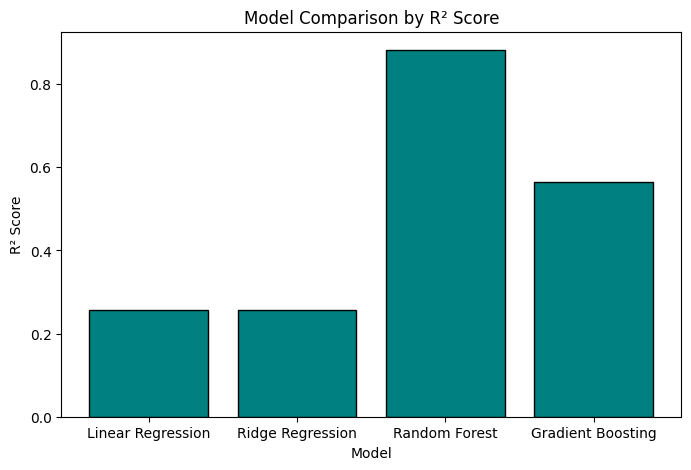

In [70]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2"], color="teal", edgecolor="black")
plt.title("Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()

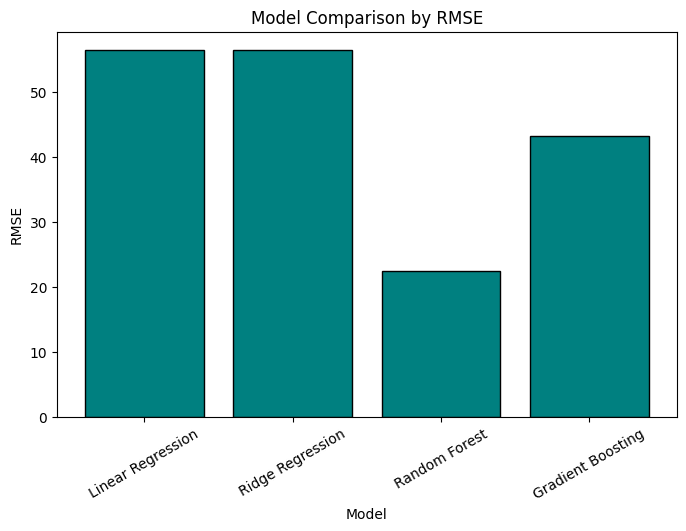

In [71]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"], color="teal", edgecolor="black")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

# Model Training and Evaluation Finding

Random Forest performed best on the random train-test split in the notebook.

But in the training pipeline Gradient Boosting is selected as a final registered model based on the pipeline evaluation metrics in Hopsworks Model Registry.

Therefore, Gradient Boosting was used as the final production model, while Random Forest was kept as part of the model comparison experiment.

## EDA Findings

- The dataset contains 8,589 rows and 28 engineered features.
- After removing rows with missing future target values, 8,543 clean records remained.
- Missing values were mainly present in future target columns, which is expected because the last records do not have future AQI values.
- AQI values vary over time, which makes forecasting meaningful.
- Pollutants such as PM2.5, PM10, O3, NO2, SO2, and CO were analyzed against AQI.
- Weather features such as temperature, humidity, pressure, wind speed, and wind direction were included because weather affects pollution concentration and movement.
- Correlation analysis showed relationships between pollutant features, rolling AQI values, and AQI.
- SHAP feature importance was used in the dashboard to explain which features influence predictions.

## Why Gradient Boosting Was Selected as the Production Model

In the comparison above, Random Forest performed best on the random train-test split.

However, AQI forecasting is a time-dependent prediction problem so a random split can mix future observations with past observations, so it can cause data leakage and produce overly optimistic results.

For production, a time-series split is more appropriate because the model is trained on earlier records and tested on later unseen records.

Time-series validation is used in the training pipeline, Gradient Boosting was selected as the production model because it showed stable generalization for future AQI prediction and was registered in the Hopsworks Model Registry.

***For temporal or sequential data, always prefer time-based validation over random splitting***

In [76]:
TARGET = "target_aqi_72h"

FEATURES = [
    c for c in df.columns
    if c not in ["target_aqi_3h", "target_aqi_24h", "target_aqi_72h", "timestamp", "city"]
]

df_clean = df.dropna(subset=[TARGET]).sort_values("timestamp")

X = df_clean[FEATURES]
y = df_clean[TARGET]

# Random split: not ideal for time-series forecasting
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

rf_random = RandomForestRegressor(n_estimators=100, random_state=42)
gb_random = GradientBoostingRegressor(n_estimators=100, random_state=42)

rf_random.fit(X_train_random, y_train_random)
gb_random.fit(X_train_random, y_train_random)

# Time-series split: correct for forecasting
split_index = int(len(X) * 0.8)

X_train_time = X.iloc[:split_index]
X_test_time = X.iloc[split_index:]

y_train_time = y.iloc[:split_index]
y_test_time = y.iloc[split_index:]

rf_time = RandomForestRegressor(n_estimators=100, random_state=42)
gb_time = GradientBoostingRegressor(n_estimators=100, random_state=42)

rf_time.fit(X_train_time, y_train_time)
gb_time.fit(X_train_time, y_train_time)


def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return rmse, mae, r2


results = []

model_runs = {
    "Random Forest": {
        "Random Split": (rf_random, X_test_random, y_test_random),
        "Time-Series Split": (rf_time, X_test_time, y_test_time),
    },
    "Gradient Boosting": {
        "Random Split": (gb_random, X_test_random, y_test_random),
        "Time-Series Split": (gb_time, X_test_time, y_test_time),
    },
}

for model_name, splits in model_runs.items():
    for split_type, (model, X_test_used, y_test_used) in splits.items():
        rmse, mae, r2 = evaluate_model(model, X_test_used, y_test_used)

        results.append({
            "Model": model_name,
            "Validation Method": split_type,
            "RMSE": round(rmse, 3),
            "MAE": round(mae, 3),
            "R² Score": round(r2, 3),
        })

results_df = pd.DataFrame(results)
results_df

,Model,Validation Method,RMSE,MAE,R² Score
0,Random Forest,Random Split,21.815,12.287,0.882
1,Random Forest,Time-Series Split,60.966,44.545,-1.390
2,Gradient Boosting,Random Split,41.100,30.127,0.581
3,Gradient Boosting,Time-Series Split,52.551,36.997,-0.776


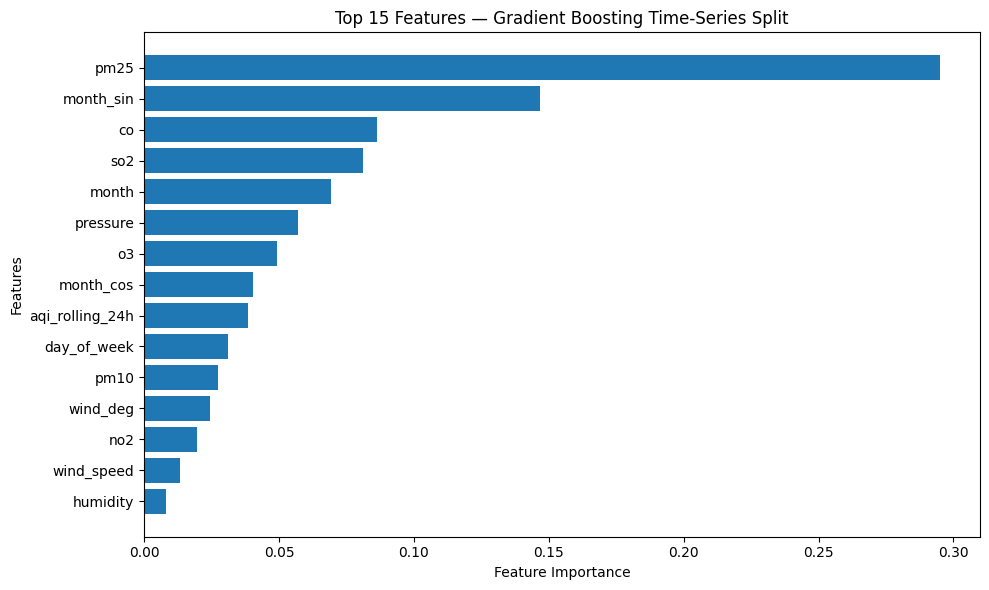

In [75]:
import os
os.makedirs("assets", exist_ok=True)

importances = gb_time.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values("importance", ascending=True)
    .tail(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_df["feature"], feature_importance_df["importance"])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Top 15 Features — Gradient Boosting Time-Series Split")

plt.tight_layout()
plt.savefig("assets/eda_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()